In [1]:
!pip install shap -q
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, fbeta_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Data

In [2]:
print("Loading dataset...")
df = pd.read_csv('/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv')
print(f"Dataset shape: {df.shape}")
df.info()
df.head()

Loading dataset...
Dataset shape: (5078345, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## 2. Class Distribution

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Laundering Rate: 0.1019%


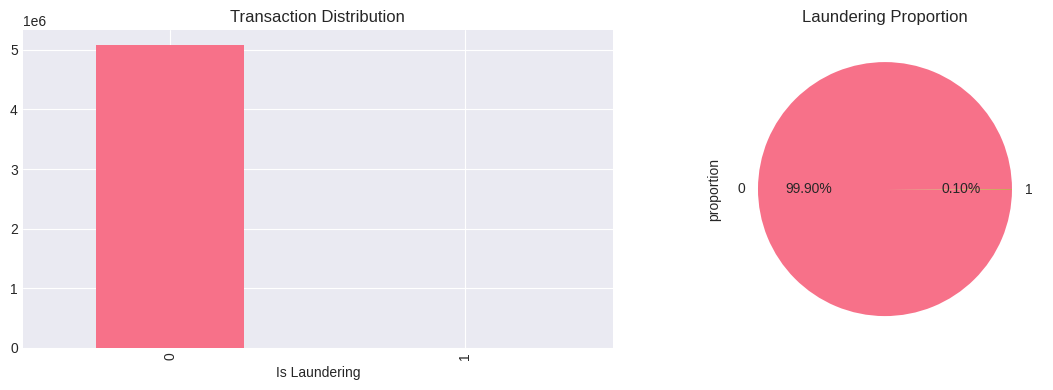

In [3]:
print(df['Is Laundering'].value_counts())
print(f"Laundering Rate: {df['Is Laundering'].mean()*100:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Is Laundering'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Transaction Distribution')
df['Is Laundering'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.2f%%')
axes[1].set_title('Laundering Proportion')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [4]:
def create_features(df):
    df_feat = df.copy()

    df_feat['Timestamp'] = pd.to_datetime(df_feat['Timestamp'])
    df_feat['DayOfWeek']  = df_feat['Timestamp'].dt.dayofweek
    df_feat['Hour']       = df_feat['Timestamp'].dt.hour
    df_feat['DayOfMonth'] = df_feat['Timestamp'].dt.day
    df_feat['Month']      = df_feat['Timestamp'].dt.month

    df_feat['DayOfWeek_sin'] = np.sin(2 * np.pi * df_feat['DayOfWeek'] / 7)
    df_feat['DayOfWeek_cos'] = np.cos(2 * np.pi * df_feat['DayOfWeek'] / 7)
    df_feat['Hour_sin']      = np.sin(2 * np.pi * df_feat['Hour'] / 24)
    df_feat['Hour_cos']      = np.cos(2 * np.pi * df_feat['Hour'] / 24)

    df_feat['Amount_Received_log'] = np.log1p(df_feat['Amount Received'])
    df_feat['Amount_Paid_log']     = np.log1p(df_feat['Amount Paid'])
    df_feat['Amount_Ratio']        = df_feat['Amount Received'] / (df_feat['Amount Paid'] + 1)
    df_feat['Amount_Diff']         = df_feat['Amount Received'] - df_feat['Amount Paid']
    df_feat['Is_Round_Amount_Received'] = (df_feat['Amount Received'] % 1000 == 0).astype(int)
    df_feat['Is_Round_Amount_Paid']     = (df_feat['Amount Paid']     % 1000 == 0).astype(int)
    df_feat['Near_10k_Threshold'] = (
        (df_feat['Amount Paid'] >= 9000) & (df_feat['Amount Paid'] < 10000)
    ).astype(int)

    df_feat['From_Bank_Group']    = df_feat['From Bank'].astype(str).str[:3]
    df_feat['To_Bank_Group']      = df_feat['To Bank'].astype(str).str[:3]
    df_feat['From_Account_Group'] = df_feat['Account'].astype(str).str[:3]
    df_feat['To_Account_Group']   = df_feat['Account.1'].astype(str).str[:3]

    payment_dummies = pd.get_dummies(df_feat['Payment Format'], prefix='Payment')
    df_feat = pd.concat([df_feat, payment_dummies], axis=1)

    df_feat['Same_Currency'] = (df_feat['Receiving Currency'] == df_feat['Payment Currency']).astype(int)
    df_feat['Currency_USD']  = (df_feat['Receiving Currency'] == 'US Dollar').astype(int)

    df_feat = df_feat.sort_values('Timestamp')

    from_counts = df_feat.groupby('Account').size()
    df_feat['From_Account_Tx_Count'] = df_feat['Account'].map(from_counts)
    from_avg = df_feat.groupby('Account')['Amount Received'].transform('mean')
    df_feat['From_Account_Avg_Amount']    = from_avg
    df_feat['From_Account_Amount_vs_Avg'] = df_feat['Amount Received'] / (from_avg + 1)

    to_counts = df_feat.groupby('Account.1').size()
    df_feat['To_Account_Tx_Count'] = df_feat['Account.1'].map(to_counts)
    to_avg = df_feat.groupby('Account.1')['Amount Received'].transform('mean')
    df_feat['To_Account_Avg_Amount']    = to_avg
    df_feat['To_Account_Amount_vs_Avg'] = df_feat['Amount Received'] / (to_avg + 1)

    fan_out = df_feat.groupby('Account')['Account.1'].nunique()
    df_feat['From_Account_Fan_Out'] = df_feat['Account'].map(fan_out)

    fan_in = df_feat.groupby('Account.1')['Account'].nunique()
    df_feat['To_Account_Fan_In'] = df_feat['Account.1'].map(fan_in)

    df_feat = df_feat.sort_values(['Account', 'Timestamp'])
    df_feat['Time_Since_Last_Tx'] = (
        df_feat.groupby('Account')['Timestamp'].diff().dt.total_seconds().fillna(999999)
    )
    df_feat['Is_Rapid_Tx'] = (df_feat['Time_Since_Last_Tx'] < 300).astype(int)

    pair_counts = df_feat.groupby(['Account', 'Account.1']).size()
    df_feat['Account_Pair_Tx_Count'] = (
        df_feat.set_index(['Account', 'Account.1']).index.map(pair_counts)
    )
    df_feat['Pair_To_Total_Ratio'] = df_feat['Account_Pair_Tx_Count'] / (df_feat['From_Account_Tx_Count'] + 1)

    df_feat = df_feat.sort_values('Timestamp').reset_index(drop=True)
    return df_feat

print("Creating features...")
df_featured = create_features(df)
print(f"Feature shape: {df_featured.shape}")

Creating features...
Feature shape: (5078345, 51)


## 4. Prepare Data for Modelling

In [5]:
def prepare_model_data(df):
    feature_cols = [
        'DayOfWeek_sin', 'DayOfWeek_cos', 'Hour_sin', 'Hour_cos',
        'Amount_Received_log', 'Amount_Paid_log', 'Amount_Ratio', 'Amount_Diff',
        'Is_Round_Amount_Received', 'Is_Round_Amount_Paid', 'Near_10k_Threshold',
        'Same_Currency', 'Currency_USD',
        'From_Account_Tx_Count', 'To_Account_Tx_Count',
        'From_Account_Avg_Amount', 'To_Account_Avg_Amount',
        'From_Account_Amount_vs_Avg', 'To_Account_Amount_vs_Avg',
        'From_Account_Fan_Out', 'To_Account_Fan_In',
        'Time_Since_Last_Tx', 'Is_Rapid_Tx',
        'Account_Pair_Tx_Count', 'Pair_To_Total_Ratio',
    ]

    payment_cols = [col for col in df.columns if col.startswith('Payment_')]
    feature_cols.extend(payment_cols)

    cat_cols = ['From_Bank_Group', 'To_Bank_Group', 'From_Account_Group', 'To_Account_Group']
    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
            feature_cols.append(f'{col}_encoded')

    existing_cols = [col for col in feature_cols if col in df.columns]
    print(f"Using {len(existing_cols)} features")

    X = df[existing_cols].fillna(df[existing_cols].mean())
    y = df['Is Laundering']

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    return X_scaled, y, existing_cols, scaler

X, y, feature_cols, scaler = prepare_model_data(df_featured)
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Using 36 features
X shape: (5078345, 36)
y distribution:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64


## 5. Temporal Split, Resampling and Training

In [6]:
split_idx = int(len(df_featured) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")
print(f"Training laundering rate: {y_train.mean()*100:.4f}%")
print(f"Test laundering rate:     {y_test.mean()*100:.4f}%")
print(f"Negative:Positive ratio:  {(y_train==0).sum()/(y_train==1).sum():.2f}")

print("\nApplying Option B resampling...")
resample_pipeline = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.02, random_state=42)),
    ('over',  SMOTE(sampling_strategy=0.1, random_state=42))
])
X_train_resampled, y_train_resampled = resample_pipeline.fit_resample(X_train, y_train)
print(f"Original shape:  {X_train.shape}")
print(f"Resampled shape: {X_train_resampled.shape}")
print(f"New distribution:\n{pd.Series(y_train_resampled).value_counts()}")

scale_pos_weight = 10
print(f"\nUsing scale_pos_weight: {scale_pos_weight}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=20,
    gamma=2,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_test, y_test)], verbose=False)
print("Model training completed!")

Training set size: 4062676
Test set size:     1015669
Training laundering rate: 0.0832%
Test laundering rate:     0.1770%
Negative:Positive ratio:  1201.33

Applying Option B resampling...
Original shape:  (4062676, 36)
Resampled shape: (185845, 36)
New distribution:
Is Laundering
0    168950
1     16895
Name: count, dtype: int64

Using scale_pos_weight: 10

Training XGBoost model...
Model training completed!


## 6. Evaluation

Default threshold: 0.500
Optimal threshold: 0.9688

ROC-AUC: 0.9906
PR-AUC:  0.4330
F1:      0.4324
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1013871
  Laundering       0.38      0.51      0.43      1798

    accuracy                           1.00   1015669
   macro avg       0.69      0.75      0.72   1015669
weighted avg       1.00      1.00      1.00   1015669



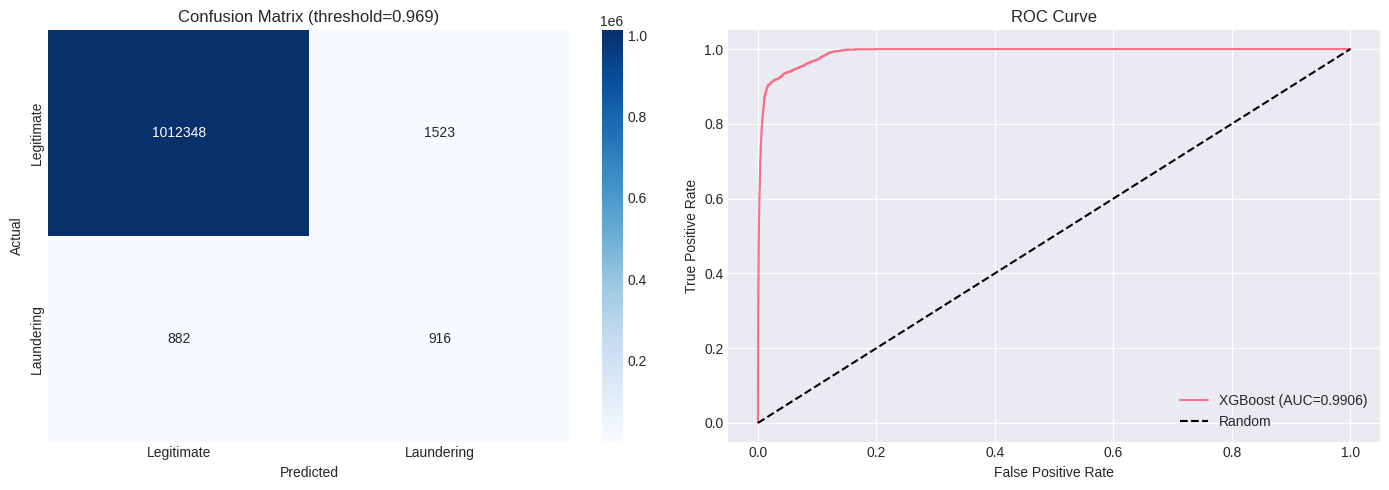

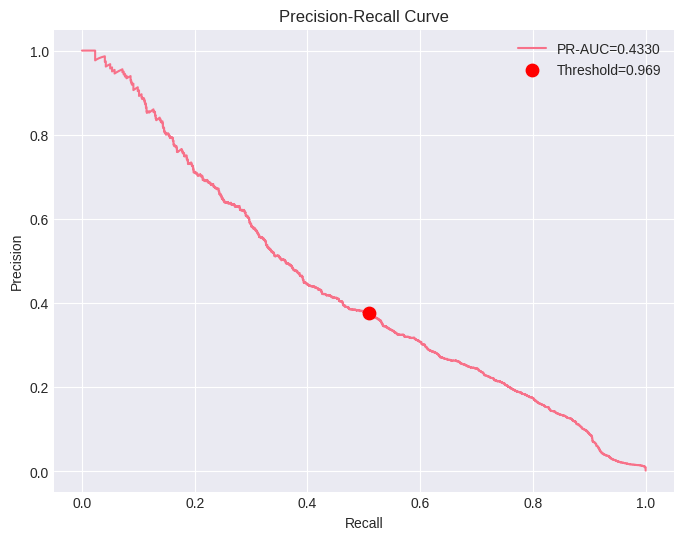

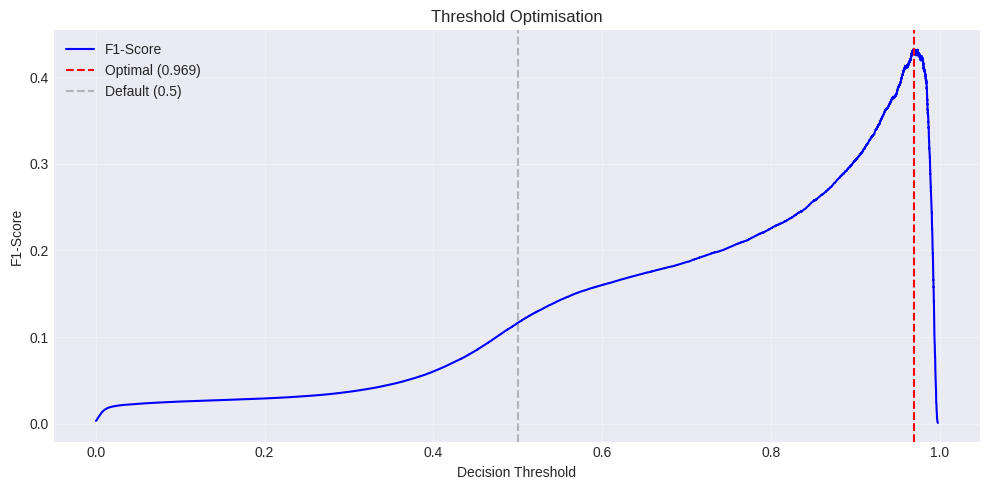

In [7]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Default threshold: 0.500")
print(f"Optimal threshold: {best_threshold:.4f}")

y_pred = (y_pred_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)
f1      = fbeta_score(y_test, y_pred, beta=1)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Legitimate', 'Laundering'])
axes[0].set_yticklabels(['Legitimate', 'Laundering'])

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'PR-AUC={pr_auc:.4f}')
plt.scatter(recall_curve[best_idx], precision_curve[best_idx],
            color='red', zorder=5, s=80, label=f'Threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores[:-1], color='blue', label='F1-Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Optimal ({best_threshold:.3f})')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('F1-Score')
plt.title('Threshold Optimisation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance

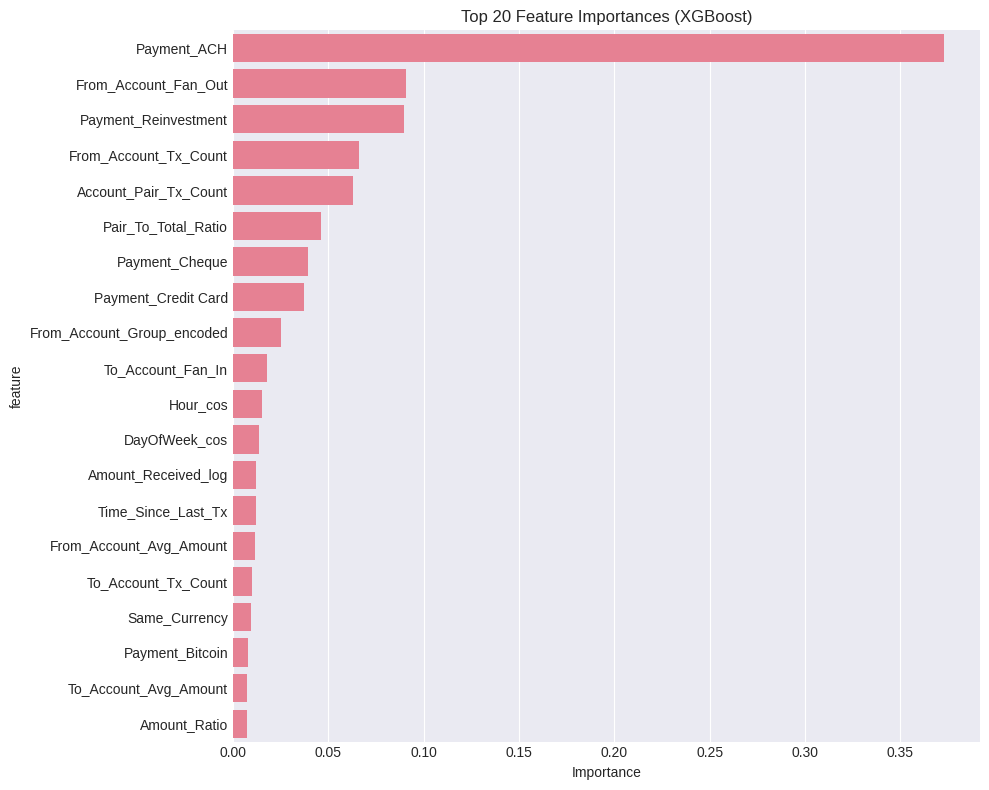


Top 10 Most Important Features:
                   feature  importance
               Payment_ACH    0.373188
      From_Account_Fan_Out    0.090576
      Payment_Reinvestment    0.089484
     From_Account_Tx_Count    0.066059
     Account_Pair_Tx_Count    0.063163
       Pair_To_Total_Ratio    0.046102
            Payment_Cheque    0.039279
       Payment_Credit Card    0.037332
From_Account_Group_encoded    0.025235
         To_Account_Fan_In    0.017943


In [8]:
feature_importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 8. SHAP Analysis

Calculating SHAP values...


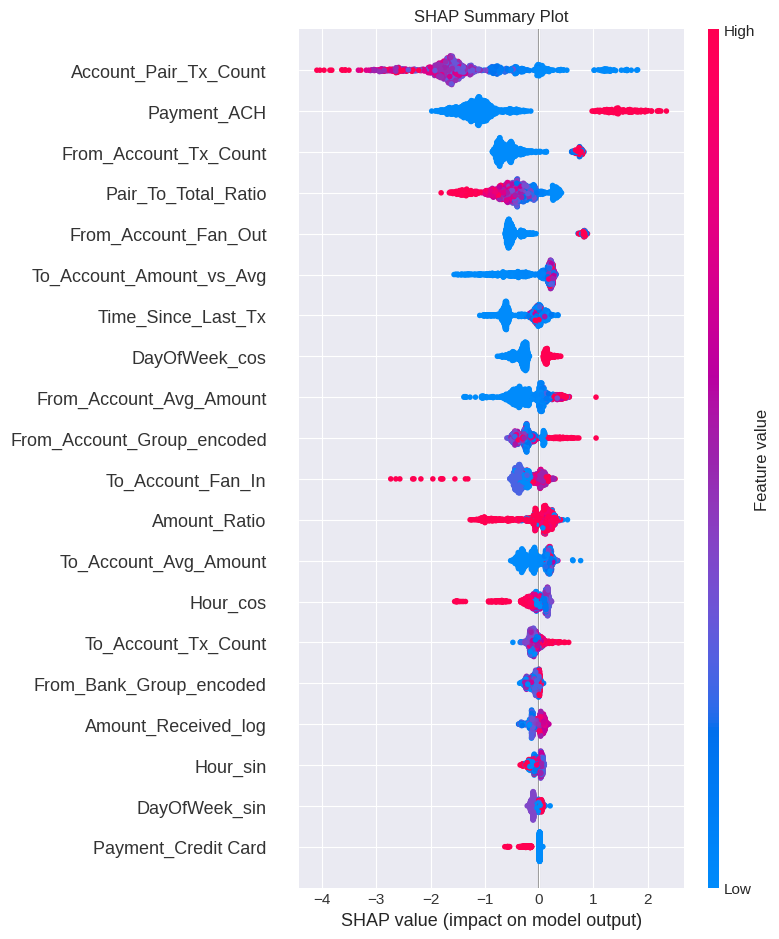

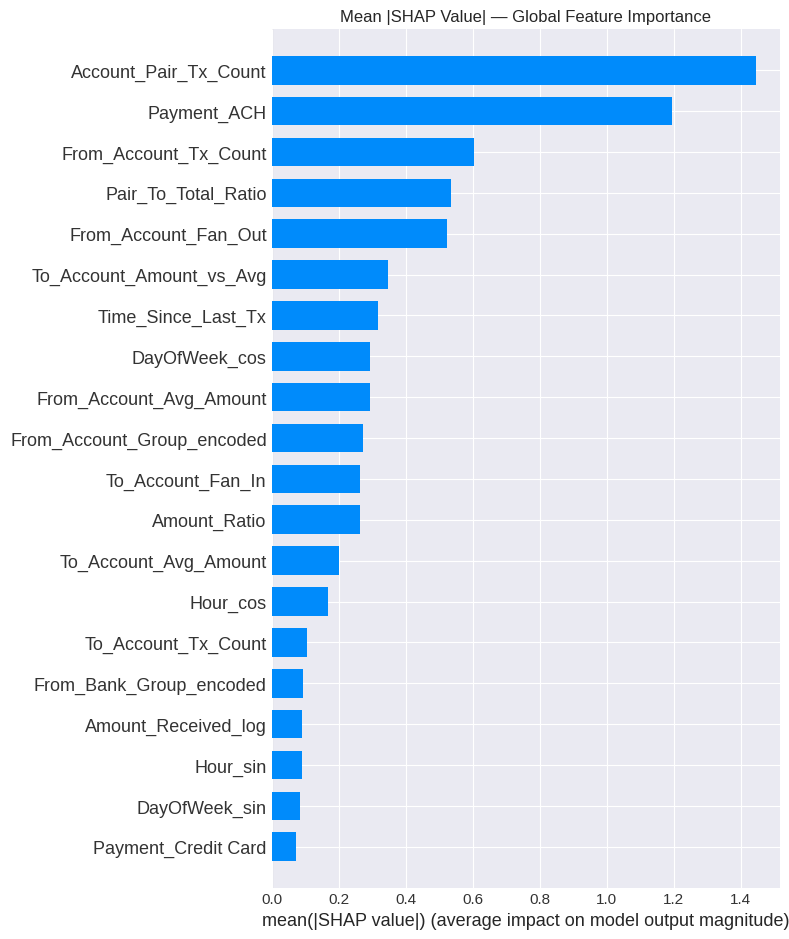

In [9]:
print("Calculating SHAP values...")
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols, plot_type="bar", show=False)
plt.title('Mean |SHAP Value| — Global Feature Importance')
plt.tight_layout()
plt.show()

## 9. SHAP Dependence Plots

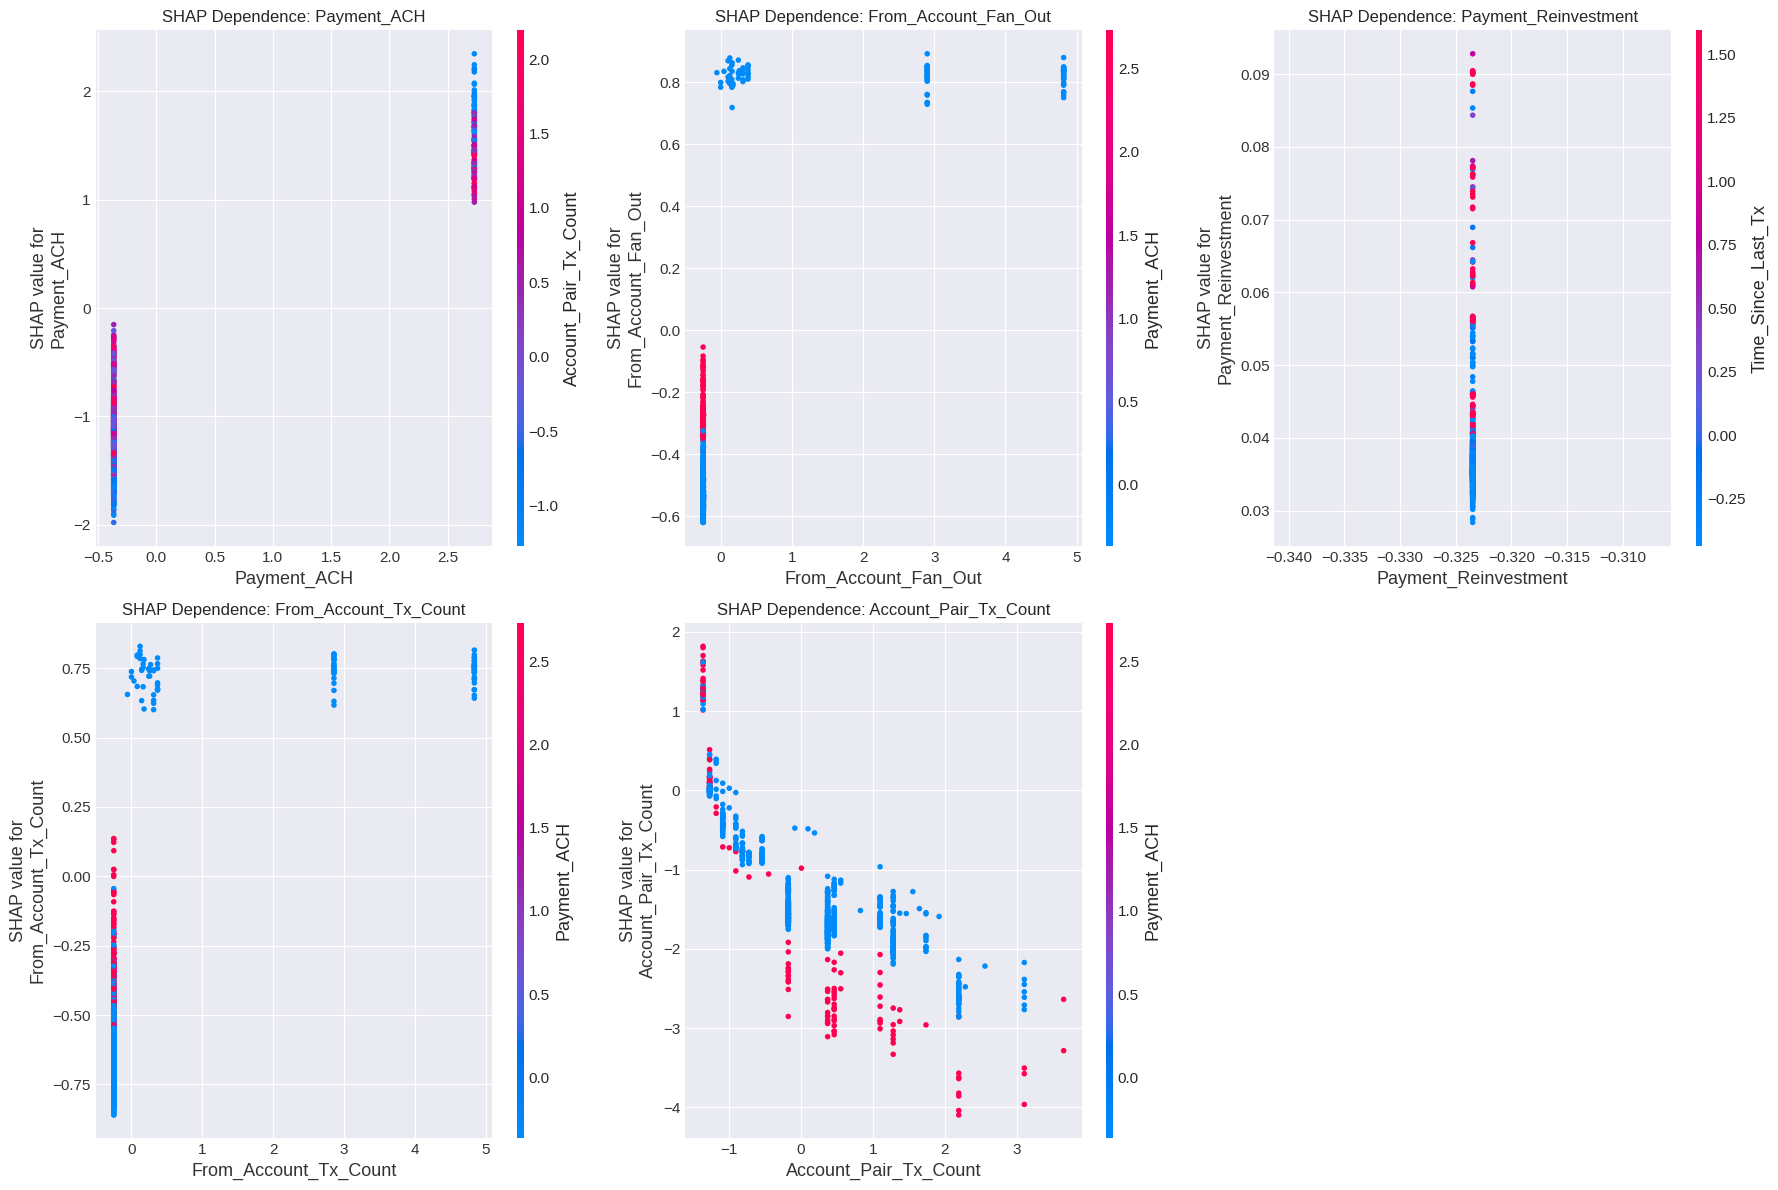

In [10]:
top_features = feature_importance.head(5)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test_sample,
                         feature_names=feature_cols, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feature}')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 10. SHAP Waterfall — Single Transaction

Transaction Index: 4075053
Predicted Prob:    0.8357


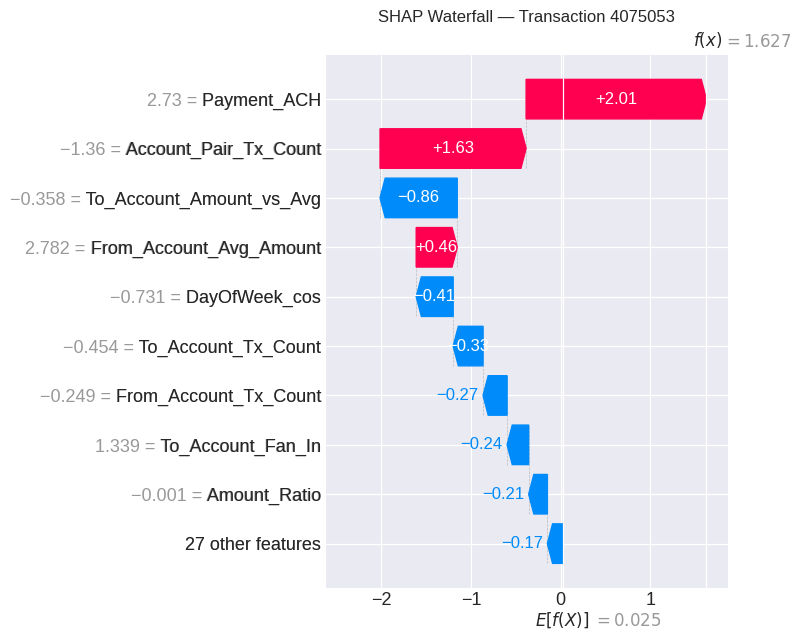

In [11]:
laundering_indices   = y_test[y_test == 1].index
laundering_in_sample = [idx for idx in laundering_indices if idx in X_test_sample.index]

if laundering_in_sample:
    idx_to_explain = laundering_in_sample[0]
    idx_position   = list(X_test_sample.index).index(idx_to_explain)
    print(f"Transaction Index: {idx_to_explain}")
    print(f"Predicted Prob:    {y_pred_proba[list(X_test.index).index(idx_to_explain)]:.4f}")

    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx_position],
            base_values=explainer.expected_value,
            data=X_test_sample.iloc[idx_position].values,
            feature_names=feature_cols
        ), show=False
    )
    plt.title(f'SHAP Waterfall — Transaction {idx_to_explain}')
    plt.tight_layout()
    plt.show()
else:
    print("No laundering transactions in SHAP sample.")

## 11. SHAP Force Plot

<Figure size 1200x300 with 0 Axes>

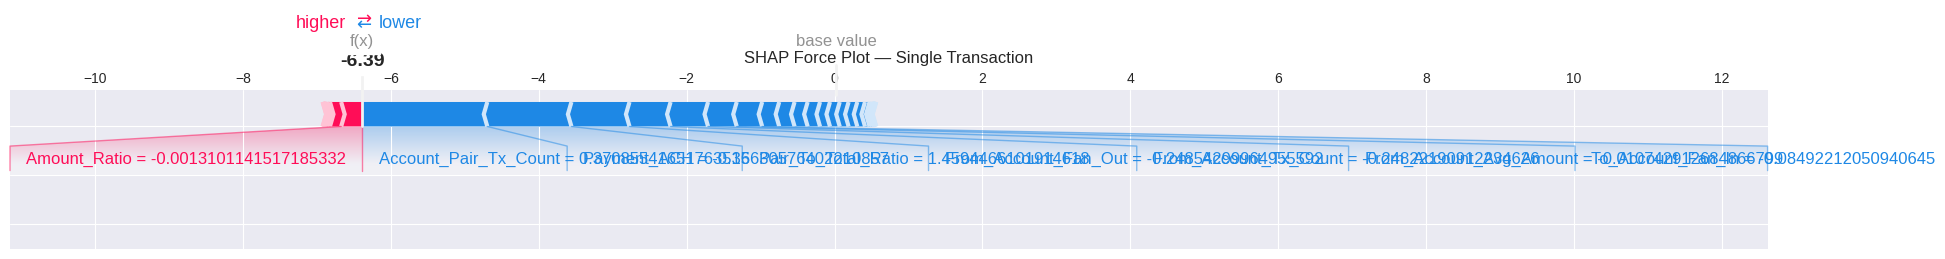

Interactive force plot (50 transactions):


In [12]:
plt.figure(figsize=(12, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_sample.iloc[0],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Single Transaction')
plt.tight_layout()
plt.show()

print("Interactive force plot (50 transactions):")
shap.force_plot(
    explainer.expected_value,
    shap_values[:50],
    X_test_sample.iloc[:50],
    feature_names=feature_cols
)

## 12. SHAP Feature Contribution Summary

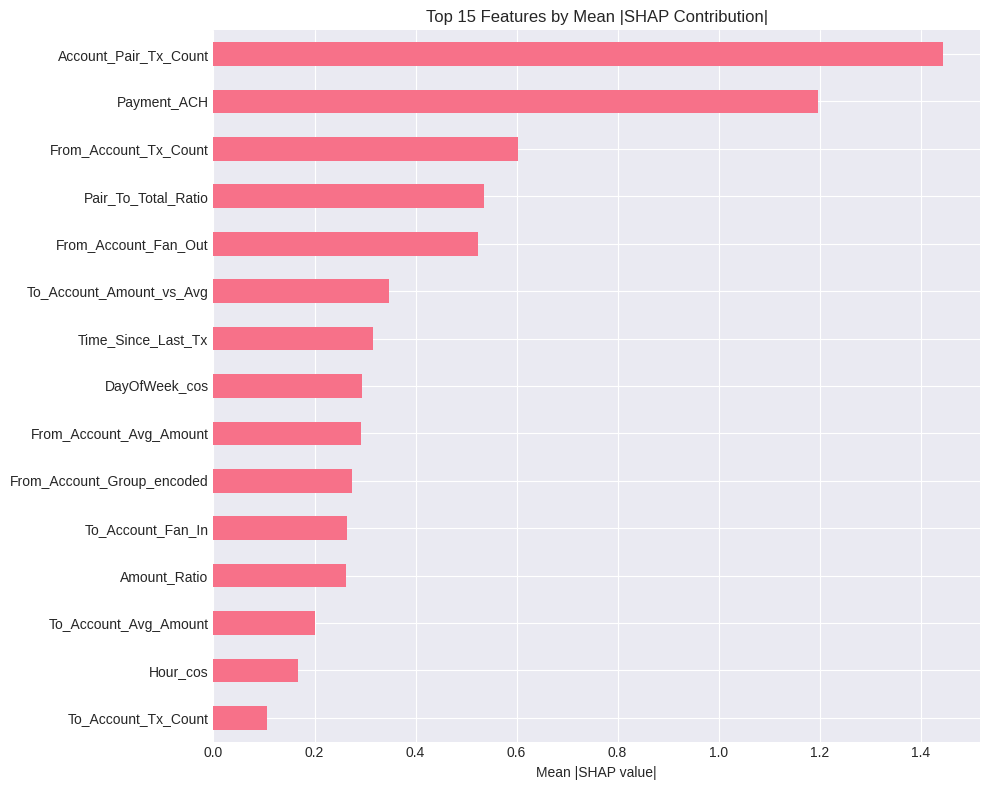

In [13]:
shap_contributions = pd.DataFrame(shap_values, columns=feature_cols, index=X_test_sample.index)
mean_abs_contrib = shap_contributions.abs().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mean_abs_contrib.head(15).plot(kind='barh')
plt.title('Top 15 Features by Mean |SHAP Contribution|')
plt.xlabel('Mean |SHAP value|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Key Insights Summary

In [14]:
report_dict = classification_report(y_test, y_pred, output_dict=True)

print("=== Key Insights from Analysis ===")
print("\n1. Model Performance:")
print(f"   - ROC-AUC:  {roc_auc:.4f}")
print(f"   - PR-AUC:   {pr_auc:.4f}")
print(f"   - F1-Score: {f1:.4f}")
print(f"   - Precision (laundering): {report_dict['1']['precision']:.4f}")
print(f"   - Recall    (laundering): {report_dict['1']['recall']:.4f}")
print(f"   - Optimal threshold:      {best_threshold:.4f}")

print("\n2. Top 5 Most Important Features:")
for _, row in feature_importance.head(5).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("\n3. Key Patterns from SHAP Analysis:")
print("   - Payment format (ACH, Bitcoin, Wire) is the strongest signal")
print("   - Fan-out (one sender to many receivers) flags layering")
print("   - Fan-in (many senders to one receiver) flags smurfing")
print("   - Account-pair repeat transactions reveal structured laundering routes")
print("   - Amount near $10k threshold indicates structuring behaviour")

=== Key Insights from Analysis ===

1. Model Performance:
   - ROC-AUC:  0.9906
   - PR-AUC:   0.4330
   - F1-Score: 0.4324
   - Precision (laundering): 0.3756
   - Recall    (laundering): 0.5095
   - Optimal threshold:      0.9688

2. Top 5 Most Important Features:
   - Payment_ACH: 0.3732
   - From_Account_Fan_Out: 0.0906
   - Payment_Reinvestment: 0.0895
   - From_Account_Tx_Count: 0.0661
   - Account_Pair_Tx_Count: 0.0632

3. Key Patterns from SHAP Analysis:
   - Payment format (ACH, Bitcoin, Wire) is the strongest signal
   - Fan-out (one sender to many receivers) flags layering
   - Fan-in (many senders to one receiver) flags smurfing
   - Account-pair repeat transactions reveal structured laundering routes
   - Amount near $10k threshold indicates structuring behaviour
